In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import utils as ut

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Introduction

This notebook studies the critical region of the two-dimensional Ising model by varying $\beta J$ (BJ) and measuring the magnetisation and magnetic susceptibility.

## Definitions

- `step`: one iteration of the Metropolis algorithm. A random spin is selected, a flip is proposed, and the flip is either accepted or rejected.
- `sweep`: $N=L^2$ Metropolis steps, so that on average every spin in the lattice is selected once.
- `block`: a fixed number of sweeps over which the magnetisation and energy are averaged. By default, one block contains 500 sweeps.

A **Monte Carlo sweep** refers to the definition above, while a **`BJ` sweep** refers to running the simulation over a range of `BJ` values.

## Equilibrium Detection

A simple automatic criterion is used to estimate when the system has equilibrated.

After each block, the average absolute reduced magnetisation

$$\langle |\tilde m| \rangle = \left\langle \left|\frac{1}{N}\sum_i \sigma_i\right| \right\rangle$$

and the average energy per spin $E/N$ are calculated. Absolute magnetisation is used because, at zero external field, the $+\tilde m$ and $-\tilde m$ ordered states are equally likely. Taking the absolute value prevents these equivalent states from cancelling and giving an average magnetisation close to zero. 

The system is considered stable when both quantities change by less than `m_tolerance` and `e_tolerance` for three consecutive blocks. If this condition is not met, the simulation continues until `max_blocks` is reached.

This is only a practical estimate of equilibrium and is not always reliable. For example, the lattice can become temporarily stuck with one large region of $+1$ spins and another of $-1$ spins. The magnetisation and energy may then change very little between blocks even though the system has not reached true equilibrium. In such cases, $|\tilde m|$ can remain close to zero even though the low-temperature equilibrium state should have $|\tilde m|$ close to one.

The criterion also becomes unreliable near the critical temperature, where magnetisation and energy naturally fluctuate strongly. The system may already be behaving statistically steadily while the block averages still vary too much to satisfy the tolerance. Loosening the tolerances would reduce this problem, but would also increase the chance of incorrectly accepting a temporarily stuck configuration as equilibrated.

For this reason, the criterion should be regarded only as a practical way of determining when to begin measurements, rather than a rigorous test of equilibrium.

## Closed Form Literature Values

### Magnetisation

The exact spontaneous magnetisation of the two-dimensional square-lattice Ising model at zero external field was derived by C. N. Yang (1952).

Yang expresses the result using the variables $H$ and $x$. In the notation used in this notebook,

$$H_{\mathrm{Yang}} = \beta J,\qquad x=e^{-2\beta J}.$$

The conversion from Yang's expression to the form used here is shown below.

<p align="center">
  <img src="images/cn_yang_conversion.png" alt="Conversion of Yang's analytical result" width="600"/>
</p>

This gives

$$
\langle |\tilde m| \rangle =
\begin{cases}
\left[1-\sinh^{-4}(2\beta J)\right]^{1/8}, & \beta J > (\beta J)_c,\\
0, & \beta J \leq (\beta J)_c.
\end{cases}
$$

This exact result is superimposed on the simulated magnetisation.

### Susceptibility

There is no similarly simple closed-form expression for the magnetic susceptibility over the full temperature range. Instead, the simulated susceptibility is compared with the exact critical point.

Onsager (1944) considers a rectangular Ising lattice with coupling constants $J$ and $J'$ in the two perpendicular lattice directions. He gives the critical condition

$$\sinh\left(\frac{2J}{k_B T_c}\right)\sinh\left(\frac{2J'}{k_B T_c}\right)=1.$$

In the isotropic square-lattice model used here, every nearest-neighbour interaction has the same coupling strength, so

$$J'=J.$$

Therefore,

$$\sinh^2(2\beta_c J)=1,$$

and hence

$$(\beta J)_c=\frac{1}{2}\ln(1+\sqrt{2})\approx 0.4407.$$

This value is shown as a vertical reference line on the simulated susceptibility curve.

## Comparing with Previous Monte Carlo runs

A paper by Jacques Kotze executes Metropolis Monte Carlo and depicts susceptibility over several values of lattice length $L$, where total number of spins in the system is $L\times L$. 

<p align="center">
  <img src="images/kotze_graph.png" alt="kotze's plot of magnetic susceptiblity vs L" width="600" align="center"/>
</p>

My code uses $\beta J$ as my measure of dimensionless temperature. Kotze uses a different representation, which is equivalent to $1/\beta J$. His results roughly agree with $\beta J_c=0.4407$ as his susceptibility spike occurs near $1/0.4407=2.269$, although there is a shift possibly due to the use of very small lattice sizes. I will convert my units to reproduce the exact same graph.

In [5]:
L = 90 # number of spins_block in one side of the square lattice (so total there are N = L^2 spins)

# hamiltonian parameters
H = 0.0 # H = mu_s * B / J

# sweep settings. these settings are kept consistent throughout all runs
num_sweeps_per_block = 500
m_tolerance = 0.01 # absolute tolerance since m can be around 0
e_tolerance = 0.01 # relative tolerance
stable_blocks_required = 3

# Function Definitions
## Sweep Function with Equilibrium Detector

In [6]:
def run_critical_temperature_sweep(
    BJ_values,
    max_blocks, 
    L=L, 
    H=H, 
    num_sweeps_per_block=num_sweeps_per_block, 
    stable_blocks_required=stable_blocks_required, 
    m_tolerance=m_tolerance, 
    e_tolerance=e_tolerance
    ):

    N = L**2
    steps = num_sweeps_per_block * N

    magnetisations = []
    susceptibilities = []
    equilibration_blocks = []

    for BJ in BJ_values:
        lattice = ut.generate_lattice(L)
        energy = ut.get_energy(lattice, H)

        block_count = 0
        stable_count = 0
        previous_m = None
        previous_e = None

        while stable_count < stable_blocks_required and block_count < max_blocks:

            lattice, spins, energies, _ = ut.metropolis(lattice, steps, BJ, H, energy)
            m_block = np.mean(np.abs(spins / N))
            e_block = np.mean(energies / N)

            if previous_m is not None: # previous_m and previous_e should both be None or both be not None
                m_change = abs(m_block - previous_m)
                e_change = abs(e_block - previous_e) / max(abs(previous_e), 1e-8) # denominator is floored at 1e-8 to prevent dividing by zero

                if m_change <= m_tolerance and e_change <= e_tolerance:
                    stable_count += 1
                else:
                    stable_count = 0

            previous_m = m_block
            previous_e = e_block
            energy = energies[-1] # latest lattice is returned by ut.metropolis() but not energy. must update manually

            block_count += 1

        # separate equilibrium measurement run
        _, spins, _, _ = ut.metropolis(lattice, 10 * steps, BJ, H, energy)
        m = spins / N
        mean_abs_m = np.mean(np.abs(m))
        chi = BJ * N * (np.mean(m**2) - np.mean(np.abs(m))**2)

        magnetisations.append(mean_abs_m)
        susceptibilities.append(chi)
        equilibration_blocks.append(block_count)

        if stable_count >= stable_blocks_required:
            print(
                f"BJ={BJ:.3f} equilibrated after "
                f"{block_count} blocks "
                f"(|m|={m_block:.3f}, E/N={e_block:.3f})"
            )
        else:
            print(
                f"BJ={BJ:.3f} reached "
                f"{block_count} blocks "
                f"(|m|={m_block:.3f}, E/N={e_block:.3f})"
            )

    return magnetisations, susceptibilities, equilibration_blocks


## Plotting Functions

In [7]:
def plot_magnetisations(BJ_values, magnetisations):
    plt.figure(figsize=(7, 5))

    # Monte Carlo result
    plt.plot(BJ_values, magnetisations, marker='o', markersize=3, linewidth=1, label='Monte Carlo')

    # C. N. Yang exact spontaneous magnetisation
    BJ_c = 0.5 * np.log(1 + np.sqrt(2))

    yang_magnetisation = np.zeros_like(BJ_values, dtype=float)

    mask = BJ_values > BJ_c
    yang_magnetisation[mask] = (1 - np.sinh(2 * BJ_values[mask])**(-4))**(1/8)

    plt.plot(BJ_values, yang_magnetisation, linestyle='--', label='Exact result (Yang, 1952)')

    plt.xlabel(r'$\beta J$')
    plt.ylabel(r'$\langle |\tilde{m}| \rangle$')
    plt.title('Magnetisation vs Inverse Temperature')

    plt.legend()
    plt.grid()
    plt.show()


def plot_susceptibilities(BJ_values, susceptibilities):
    critical_index = np.argmax(susceptibilities)
    BJ_c = BJ_values[critical_index]

    # Exact critical point for the infinite 2D square-lattice Ising model
    BJ_c_exact = 0.5 * np.log(1 + np.sqrt(2))

    plt.figure(figsize=(7, 5))

    plt.plot(BJ_values, susceptibilities, marker='o', markersize=3, linewidth=1)

    plt.axvline(BJ_c, linestyle='--', label=rf'Numerical $\beta J_c \approx {BJ_c:.3f}$')

    plt.axvline(BJ_c_exact, linestyle=':', label=rf'Exact $\beta J_c = {BJ_c_exact:.4f}$')

    plt.xlabel(r'$\beta J$')
    plt.ylabel(r'$\tilde{\chi}$')
    plt.title('Magnetic Susceptibility vs Inverse Temperature')

    plt.legend()
    plt.grid()
    plt.show()

    print(f"Estimated critical beta J = {BJ_c:.3f}")
    print(f"Exact critical beta J = {BJ_c_exact:.4f}")


def plot_equilibration_blocks(BJ_values, equilibration_blocks):
    plt.figure(figsize=(7, 5))

    plt.plot(BJ_values, equilibration_blocks, marker='o', markersize=3, linewidth=1)

    plt.xlabel(r'$\beta J$')
    plt.ylabel('Blocks Before Measurement')
    plt.title('Blocks Before Measurement vs Inverse Temperature')

    plt.grid()
    plt.show()

# Experiment

In [5]:
# parameters
BJ_values = np.arange(0.2, 0.71, 0.01)
max_blocks = 40

# execution
magnetisations, susceptibilities, equilibration_blocks = run_critical_temperature_sweep(BJ_values, max_blocks)

BJ=0.200 equilibrated after 4 blocks (|m|=0.014, E/N=-0.428)
BJ=0.210 equilibrated after 4 blocks (|m|=0.015, E/N=-0.455)
BJ=0.220 equilibrated after 4 blocks (|m|=0.016, E/N=-0.479)
BJ=0.230 equilibrated after 4 blocks (|m|=0.017, E/N=-0.505)
BJ=0.240 equilibrated after 4 blocks (|m|=0.018, E/N=-0.528)
BJ=0.250 equilibrated after 4 blocks (|m|=0.017, E/N=-0.556)
BJ=0.260 equilibrated after 4 blocks (|m|=0.020, E/N=-0.588)
BJ=0.270 equilibrated after 4 blocks (|m|=0.022, E/N=-0.615)
BJ=0.280 equilibrated after 4 blocks (|m|=0.020, E/N=-0.641)
BJ=0.290 equilibrated after 4 blocks (|m|=0.021, E/N=-0.674)
BJ=0.300 equilibrated after 4 blocks (|m|=0.023, E/N=-0.705)
BJ=0.310 equilibrated after 4 blocks (|m|=0.027, E/N=-0.737)
BJ=0.320 equilibrated after 4 blocks (|m|=0.031, E/N=-0.770)
BJ=0.330 equilibrated after 4 blocks (|m|=0.029, E/N=-0.804)
BJ=0.340 equilibrated after 4 blocks (|m|=0.028, E/N=-0.839)
BJ=0.350 equilibrated after 5 blocks (|m|=0.034, E/N=-0.882)
BJ=0.360 equilibrated af

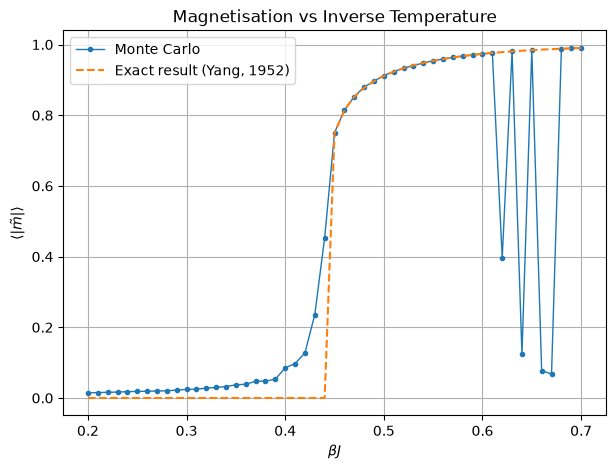

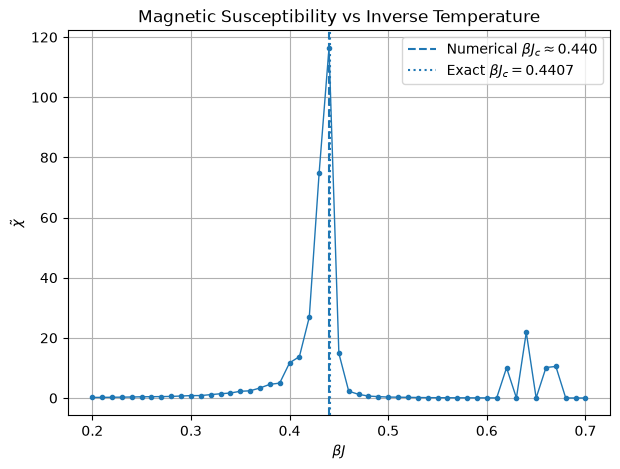

Estimated critical beta J = 0.440
Exact critical beta J = 0.4407


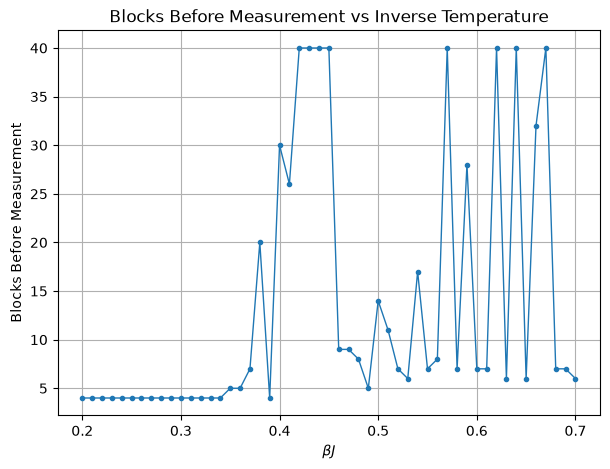

In [10]:
plot_magnetisations(BJ_values, magnetisations)
plot_susceptibilities(BJ_values, susceptibilities)
plot_equilibration_blocks(BJ_values, equilibration_blocks)

## Low-Temperature Anomalies

At large $\beta J$, several points deviate strongly from the exact magnetisation curve, especially at $BJ=0.62$, $0.64$, $0.66$, and $0.67$.

This happens because the lattice can get stuck having both $+1$ and $-1$ domains. At low temperature, single-spin Metropolis updates can take a long time to remove these domains.

For $BJ=0.62$, $0.64$, and $0.67$, the simulation reaches `max_blocks` without satisfying the equilibrium criterion. At $BJ=0.66$, the criterion incorrectly accepts the state as stable even though the magnetisation is clearly wrong.

These points are therefore simulation errors rather than physical behaviour.

## Recreating Kotze's Susceptibility Graph

In [23]:
Ls = [2, 4, 8, 16]
T_values = np.arange(0.5, 5.1, 0.1)
BJ_values = 1 / T_values
max_blocks = 300
n_runs = 10

all_magnetisations = []
all_susceptibilities = []

for L in Ls:
    magnetisation_runs = []
    susceptibility_runs = []

    for _ in range(n_runs):
        magnetisations, susceptibilities, _ = run_critical_temperature_sweep(
            BJ_values,
            max_blocks,
            L=L
        )

        magnetisation_runs.append(magnetisations)
        susceptibility_runs.append(susceptibilities)

    mean_magnetisations = np.mean(magnetisation_runs, axis=0)
    mean_susceptibilities = np.mean(susceptibility_runs, axis=0)

    all_magnetisations.append(mean_magnetisations)
    all_susceptibilities.append(mean_susceptibilities)

BJ=2.000 equilibrated after 4 blocks (|m|=1.000, E/N=-2.000)
BJ=1.667 equilibrated after 4 blocks (|m|=1.000, E/N=-2.000)
BJ=1.429 equilibrated after 4 blocks (|m|=1.000, E/N=-2.000)
BJ=1.250 equilibrated after 4 blocks (|m|=1.000, E/N=-2.000)
BJ=1.111 equilibrated after 4 blocks (|m|=1.000, E/N=-2.000)
BJ=1.000 equilibrated after 4 blocks (|m|=1.000, E/N=-2.000)
BJ=0.909 equilibrated after 4 blocks (|m|=1.000, E/N=-2.000)
BJ=0.833 equilibrated after 4 blocks (|m|=0.990, E/N=-1.969)
BJ=0.769 equilibrated after 9 blocks (|m|=0.988, E/N=-1.965)
BJ=0.714 equilibrated after 19 blocks (|m|=0.989, E/N=-1.967)
BJ=0.667 equilibrated after 5 blocks (|m|=0.977, E/N=-1.932)
BJ=0.625 equilibrated after 38 blocks (|m|=0.986, E/N=-1.957)
BJ=0.588 equilibrated after 6 blocks (|m|=0.968, E/N=-1.903)
BJ=0.556 equilibrated after 79 blocks (|m|=0.957, E/N=-1.871)
BJ=0.526 equilibrated after 148 blocks (|m|=0.945, E/N=-1.831)
BJ=0.500 equilibrated after 182 blocks (|m|=0.918, E/N=-1.754)
BJ=0.476 equilibr

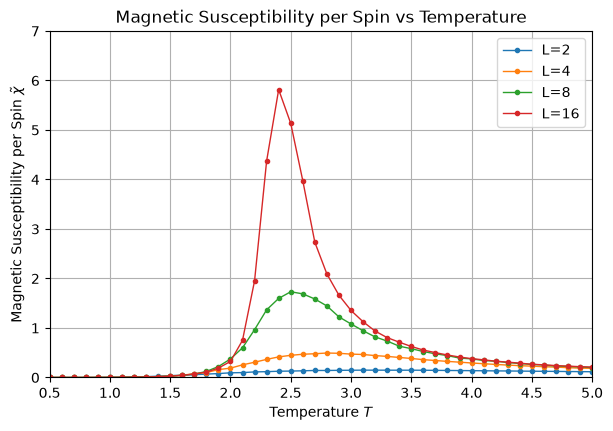

In [24]:
plt.figure(figsize=(7, 4.5))

for L, susceptibilities in zip(Ls, all_susceptibilities):
    plt.plot(
        T_values,
        susceptibilities,
        marker='o',
        markersize=3,
        linewidth=1,
        label=f'L={L}'
    )

plt.xlabel('Temperature $T$')
plt.ylabel(r'Magnetic Susceptibility per Spin $\tilde{\chi}$')
plt.title('Magnetic Susceptibility per Spin vs Temperature')

plt.xlim(0.5, 5)
plt.ylim(0, 7)

plt.legend()
plt.grid()
plt.show()

Superimposing my plot with Kotze’s, we see close agreement in the susceptibility curves for all lattice sizes, which provides a useful validation of the simulation and susceptibility calculation.

<p align="center">
  <img src="images/kotze-combined.png" alt="kotze's plot of magnetic susceptiblity vs L" width="600" align="center"/>
</p>

# References

- C. N. Yang, “The Spontaneous Magnetization of a Two-Dimensional Ising Model,” *Physical Review* **85**, 808–816 (1952).
- L. Onsager, “Crystal Statistics. I. A Two-Dimensional Model with an Order-Disorder Transition,” *Physical Review* **65**, 117–149 (1944).
- J. Kotze, “Introduction to Monte Carlo Methods for an Ising Model of a Ferromagnet,” *arXiv:0803.0217* (2008).